In [1]:
n = 500 # sample size
p = 50 # predictor數量(J)
rho = 0.5 # predictor相關程度
scenario = "A"

In [2]:
import numpy as np

def build_covariance(p, rho):
    Sigma = np.zeros((p, p))

    for i in range(p):
        for j in range(p):
            Sigma[i, j] = rho ** abs(i-j)

    return Sigma

In [3]:
Sigma = build_covariance(5,0.5)

print(Sigma)

[[1.     0.5    0.25   0.125  0.0625]
 [0.5    1.     0.5    0.25   0.125 ]
 [0.25   0.5    1.     0.5    0.25  ]
 [0.125  0.25   0.5    1.     0.5   ]
 [0.0625 0.125  0.25   0.5    1.    ]]


In [4]:
def generate_X(n, p, rho, seed=None):

    if seed is not None:
        np.random.seed(seed)

    Sigma = build_covariance(p, rho)

    X = np.random.multivariate_normal(
        mean=np.zeros(p),
        cov=Sigma,
        size=n
    )

    return X

In [5]:
X = generate_X(
    n=500,
    p=50,
    rho=0.5,
    seed=123
)

In [6]:
def standardize(X):

    mean = np.mean(X, axis=0)
    std = np.std(X, axis=0, ddof=0)

    return (X - mean) / std

In [7]:
X = standardize(X)

In [8]:
beta = np.zeros(50)

beta[:5] = [2,1.5,-2,1,-1]

In [9]:
mu = X @ beta

In [15]:
sigma0 = 1

delta = 1

sigma_i = sigma0 * np.sqrt(
    1 + delta*(X[:,0]**2 + X[:,1]**2)
)

eps = np.random.normal(
    0,
    sigma_i,
    size = n
)

In [16]:
Y = mu + eps

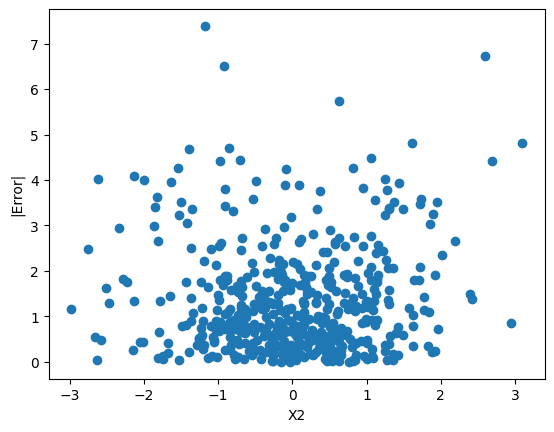

In [18]:
import matplotlib.pyplot as plt

plt.scatter(X[:, 1], np.abs(eps))
plt.xlabel("X2")
plt.ylabel("|Error|")
plt.show()